In [895]:
import torch
import torch.nn.functional as F
import matplotlib.pylab as plt
%matplotlib inline

In [896]:
#read all the words
words = open("names.txt", 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [897]:
#build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

In [898]:
#99 build the dataset
block_size = 3 #context length: how many characters do we take to predict the next one
xs, ys = [], []

for w in words:
    #print(w)
    context = [0] * block_size #0 in period char
    for ch in w + '.':
        ix = stoi[ch]
        xs.append(context)
        ys.append(ix)

        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] #crop and append

xs = torch.tensor(xs)
ys = torch.tensor(ys)


In [899]:
xs.shape, ys.shape, xs.dtype, ys.dtype

(torch.Size([228146, 3]), torch.Size([228146]), torch.int64, torch.int64)

In [900]:
#embedding is an alternative to one hot encoding
C = torch.randn((27, 2))

In [901]:
C[[1,2,3, 3, 2]]

tensor([[ 0.9544, -1.4155],
        [ 0.8699, -0.4825],
        [ 0.5850, -0.0832],
        [ 0.5850, -0.0832],
        [ 0.8699, -0.4825]])

In [902]:
C[xs[:2]].shape


torch.Size([2, 3, 2])

In [903]:
xs[14, 2]

tensor(22)

In [904]:
C[xs[14, 2]]

tensor([ 0.4521, -0.7416])

In [905]:
C[22]

tensor([ 0.4521, -0.7416])

In [906]:
emb = C[xs]
emb.shape

torch.Size([228146, 3, 2])

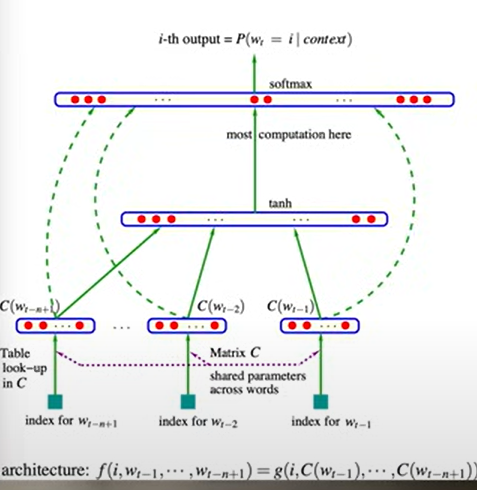


In [907]:
W1 = torch.randn((6, 100))#3*3 n_input , 100 hidden layer neurons
b1=  torch.randn(100)

In [908]:
emb[:1]

tensor([[[ 0.0105, -1.5793],
         [ 0.0105, -1.5793],
         [ 0.0105, -1.5793]]])

In [909]:
emb[:1, 0, :], emb[:2, 0, :], emb[:4, 0, :]

(tensor([[ 0.0105, -1.5793]]),
 tensor([[ 0.0105, -1.5793],
         [ 0.0105, -1.5793]]),
 tensor([[ 0.0105, -1.5793],
         [ 0.0105, -1.5793],
         [ 0.0105, -1.5793],
         [-0.1493, -1.8050]]))

In [910]:
emb[5, 0, :], emb[5, 1, :], emb[5, 2, :]

(tensor([ 0.0105, -1.5793]),
 tensor([ 0.0105, -1.5793]),
 tensor([ 0.0105, -1.5793]))

In [911]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [912]:
len(torch.unbind(emb, 1))

3

In [913]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [914]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [915]:
a.view(3, 2, 3, 1)

tensor([[[[ 0],
          [ 1],
          [ 2]],

         [[ 3],
          [ 4],
          [ 5]]],


        [[[ 6],
          [ 7],
          [ 8]],

         [[ 9],
          [10],
          [11]]],


        [[[12],
          [13],
          [14]],

         [[15],
          [16],
          [17]]]])

In [916]:
a.storage()

 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [917]:
#emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

In [918]:
#h = emb.view(32, 6) @ W1 + b1

In [919]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #infering first dimension


In [920]:
h.shape

torch.Size([228146, 100])

In [921]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

In [922]:
logits = h @ W2 + b2

In [923]:
logits.shape

torch.Size([228146, 27])

In [924]:
counts = logits.exp()

In [925]:
probs = counts / counts.sum(1, keepdim=True)
probs[0].sum()

tensor(1.)

In [926]:
A = torch.tensor([[1, 2, 3], [4,5,6]])
A.shape

torch.Size([2, 3])

In [927]:
A.sum(1, keepdim=True).shape

torch.Size([2, 1])

In [928]:
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(16.4556)

In [929]:
# -------------------now more respectable--------------------------#
xs.shape, ys.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [930]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27, 2), generator=g) 

W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)
parameters = [C, W1, b1, W2, b2]

In [931]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [932]:
emb = C[xs] #(32,3,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #32, 100
logits = h @ W2 * b2 #(32, 27)
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(len(xs)), ys].log().mean()
loss

tensor(23.0203)

In [933]:
F.cross_entropy(logits, ys) #same loss as cross entropy , more efficient, in memrory and in backward pass
#numerically well behavaed , e^100 gives nan
# torch.tensor([-5, -3, 0, 100]).exp(), under the hood torch does -100 for each element, in terms probs it will be same

tensor(23.0203)

In [934]:
for p in parameters:
    p.requires_grad = True

In [935]:
#in reality it is important to take approx gradient and make more steps rather take exact gradient and more fewer steps
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [936]:
lri = []
lossi = []

for i in range(1000):
    #mini batch construct
    ix = torch.randint(0, len(xs), (32, ))

    #forward pass
    emb = C[xs[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #32, 100
    logits = h @ W2 * b2 #(32, 27)
    loss = F.cross_entropy(logits, ys[ix])


    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    lri.append(lr)
    lossi.append(loss.item())


In [937]:
lossi

[23.16669273376465,
 26.58163833618164,
 22.413454055786133,
 22.81031036376953,
 23.046499252319336,
 19.518390655517578,
 22.503440856933594,
 20.87932014465332,
 22.137483596801758,
 21.96713638305664,
 21.522676467895508,
 23.0040225982666,
 21.541296005249023,
 19.896604537963867,
 21.03679084777832,
 21.4476318359375,
 20.046754837036133,
 22.13136863708496,
 20.222227096557617,
 23.60188102722168,
 23.43116569519043,
 18.46980857849121,
 20.168548583984375,
 17.80766487121582,
 21.51531982421875,
 18.749549865722656,
 17.36854362487793,
 19.029680252075195,
 18.690858840942383,
 18.933155059814453,
 21.219554901123047,
 19.973480224609375,
 20.917795181274414,
 19.9842529296875,
 18.218643188476562,
 19.10198974609375,
 20.395689010620117,
 15.670269012451172,
 17.835880279541016,
 18.19155502319336,
 18.458045959472656,
 18.608726501464844,
 21.649154663085938,
 17.965349197387695,
 20.430822372436523,
 18.574390411376953,
 17.652854919433594,
 19.372821807861328,
 16.821182250

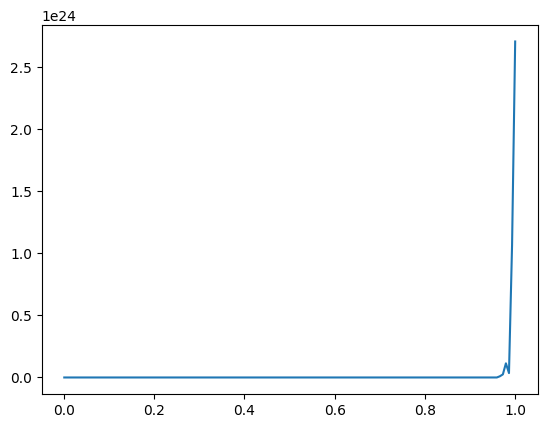

In [938]:
plt.plot(lri, lossi)

In [939]:
#training split, dev/validation split, test split
# 80%, 10%, 10%
#dev/validation split used to size of embedding, hidden layer, regularization

In [940]:
def build_dataset(words):
    block_size = 3 #context length: how many characters do we take to predict the next one
    xs, ys = [], []

    for w in words:
        #print(w)
        context = [0] * block_size #0 in period char
        for ch in w + '.':
            ix = stoi[ch]
            xs.append(context)
            ys.append(ix)

            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] #crop and append
    
    xs = torch.tensor(xs)
    ys = torch.tensor(ys)
    print(xs.shape, ys.shape)

    return xs, ys


In [941]:
import random
random.seed(42)
random.shuffle(words)


In [942]:
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [984]:
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [980]:
for p in parameters:
    p.requires_grad = True

In [981]:


for i in range(1000):
    #mini batch construct
    ix = torch.randint(0, len(Xtr), (32, ))

    #forward pass
    emb = C[Xtr[ix]] #(32,3,2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #32, 100
    logits = h @ W2 * b2 #(32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    print(loss.item())


    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    #lr = lrs[i]
    for p in parameters:
        p.data += -.1 * p.grad

    #track stats
    #lri.append(lr)
    #lossi.append(loss.item())


17.11452293395996
14.316030502319336
12.539888381958008
10.316327095031738
9.036893844604492
8.103964805603027
6.383894443511963
5.661620616912842
4.730689525604248
5.093420505523682
4.2944865226745605
4.0721116065979
3.8379876613616943
3.611851215362549
3.6889240741729736
3.9979100227355957
3.7378058433532715
3.457528591156006
3.5117251873016357
3.5468454360961914
3.438711643218994
3.7133824825286865
3.3781378269195557
3.3932738304138184
2.979525566101074
3.3269646167755127
3.0799458026885986
3.4660959243774414
3.318544864654541
3.052353620529175
3.5317206382751465
3.2366151809692383
3.221792459487915
3.30961537361145
3.5711092948913574
3.034614086151123
3.0528059005737305
3.094086170196533
3.255708694458008
3.2806355953216553
3.0890698432922363
2.970611572265625
3.303781032562256
3.152036666870117
3.0347707271575928
3.4245524406433105
3.282283067703247
3.305659770965576
3.3142573833465576
3.2313013076782227
3.027716875076294
2.969813346862793
2.9792020320892334
3.0267207622528076
3.3

In [946]:
print(loss.item())

2.8914010524749756


In [982]:
emb = C[Xdev] #(32,3,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #32, 100
logits = h @ W2 * b2 #(32, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.7231969833374023


In [983]:
g = torch.Generator().manual_seed(2147483647) 

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] #[1, block_size, d= 10]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if (ix == 0):
            break

    print(''.join(itos[i] for i in out))

....


In [948]:
C.shape


torch.Size([27, 2])

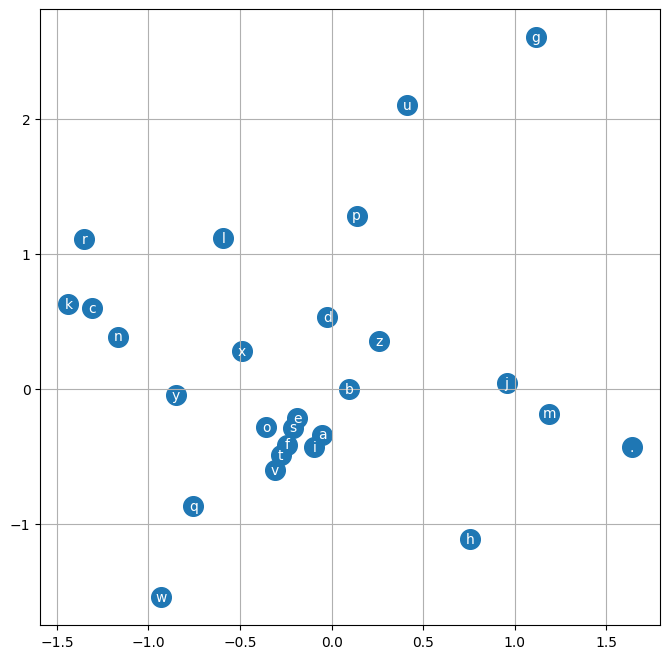

In [949]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')

plt.grid('minor')

In [950]:
#lets play with embedding size and hidden layer size
g = torch.Generator().manual_seed(2147483647) #for reproducibility
C = torch.randn((27, 10), generator=g, requires_grad=True)



In [951]:
xss, yss = build_dataset(words)

torch.Size([228146, 3]) torch.Size([228146])


In [952]:
C[xss].shape

torch.Size([228146, 3, 10])

In [953]:
W1 = torch.randn((30, 200), generator=g,requires_grad=True) #changing hidden layer parameter as well
b1 = torch.randn(200, generator=g,  requires_grad=True)
W2 = torch.randn((200, 27),generator=g, requires_grad=True)
b2 = torch.randn(27,generator=g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

In [954]:
for p in parameters:
    p.requires_grad = True

In [955]:


for i in range(1000):
    #mini batch construct
    ix = torch.randint(0, len(Xtr), (32, ))

    #forward pass
    emb = C[Xtr[ix]] #(32,3,10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #32, 100
    logits = h @ W2 * b2 #(32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    print(loss.item())


    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    #lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad

    #track stats
    #lri.append(lr)
    #lossi.append(loss.item())



45.395423889160156
30.44692611694336
23.555755615234375
19.795886993408203
15.371889114379883
16.16683578491211
11.063687324523926
9.151777267456055
9.70605182647705
8.182320594787598
5.972494602203369
6.171783924102783
4.992988109588623
4.445185661315918
3.970292806625366
4.53318977355957
4.4441046714782715
3.687485456466675
4.3308305740356445
3.430415630340576
3.744439125061035
3.362213373184204
3.7640395164489746
3.3389666080474854
3.7443737983703613
3.490065574645996
3.3677525520324707
3.3605053424835205
3.512577772140503
3.5518836975097656
3.352261781692505
3.4108970165252686
3.475334405899048
3.3667876720428467
3.3193955421447754
3.4266018867492676
3.371941328048706
3.2930221557617188
3.4319963455200195
3.280050039291382
3.3820459842681885
3.480564594268799
3.261110782623291
3.3127846717834473
3.30586314201355
3.3885884284973145
3.2439844608306885
3.2522408962249756
3.3569881916046143
3.0148377418518066
3.2814340591430664
3.636647939682007
3.928215503692627
3.817624568939209
3.50

In [956]:
emb = C[torch.tensor([[0, 0, 0]])]
emb.shape
emb.view(1, -1).shape

torch.Size([1, 30])

In [957]:
probs[:2]

tensor([[1.1754e-14, 2.5888e-09, 4.3893e-11, 9.9999e-01, 5.4181e-10, 8.3238e-10,
         1.0415e-13, 1.6129e-10, 1.6684e-10, 1.4422e-15, 1.2124e-08, 3.0835e-09,
         5.4149e-10, 6.2227e-10, 1.2950e-11, 1.3550e-10, 4.3434e-10, 1.9594e-09,
         1.2808e-05, 4.4584e-10, 1.4376e-13, 3.8300e-07, 7.0840e-11, 2.7054e-09,
         5.2902e-08, 1.0292e-19, 5.9048e-23],
        [2.6660e-15, 7.9182e-13, 1.6910e-11, 9.0586e-01, 2.3762e-12, 6.0232e-10,
         4.2860e-13, 7.2447e-09, 9.4139e-02, 1.0265e-14, 1.1398e-16, 2.0206e-09,
         4.0387e-11, 9.1073e-12, 1.6932e-12, 2.7943e-11, 1.2843e-11, 3.7616e-11,
         4.8776e-12, 1.6118e-15, 1.5318e-20, 8.0845e-16, 3.8697e-11, 3.3248e-10,
         2.0880e-10, 1.5397e-18, 1.5973e-18]])

In [962]:
logits.shape

torch.Size([1, 27])

In [969]:
K = torch.tensor([[1, 3, 4, 5], [7,6,5,4]])
torch.max(K, dim=0)


torch.return_types.max(
values=tensor([7, 6, 5, 5]),
indices=tensor([1, 1, 1, 0]))

In [963]:
#sample from model
g = torch.Generator().manual_seed(2147483647) 

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] #[1, block_size, d= 10]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if (ix == 0):
            break

    print(''.join(itos[i] for i in out))

pokkdjryhcuygkjicyykrfijkkgfjkkgfjkkgfjakcjkcyksozshvuhczykpokkdfkurumojkhgpojkhgpolpjkfyukojkhgpolpjnfgkkdukajjihguhjryhcuygkoynsrkcyksozshvuhhjkygkoynjryhcuygkjifiurfucovwthsjkhgpokyjkhgpojkhgpolpjkfyukojkhgpolpjkfyukojnhgpolpjkfyukojkhgpoyvyyhjkdigjkcyykkyjkhgpoyvyyhjkygkjifiurfsjkhgpolpjnfcpokkdjxvcchmufokkdukajjihgupojkhgpolpjkfyukojkhgpolpjkfyukojkigjkhgpolpjnfgkpjkfyukajjihgupjkfyukojkhgpojkhgpolkdjryhcuygkdjryhcuygkjikgfjkkgfjauijryhcuygkjrkconshvyyhjkdixjkcyykrfucovwthsjkhgpolpjkfyukajjihgupjkfyukojkhgpojkhgpojkhgpojkhgpokkdjryhcuygkjicyykkyjkygkoynjryhcuygkoysyvkyhjkygkoynjrhgpolpjnfcpokkdukajjihgupojkhgpolpjrfccaujdfcukcoyshvuhmpokkdukajjihgupjkfyukojkhgpozkdfkurumojkhgpolpjkfioousjrhgpolpjkfyukojkhgkjifiurumojkhgpolpjnfcpokkdjryhcuygkoynjrhgpolpjrfccaujdfcukcoyshvuhmpokkdjxvcchmuiojyhgupjkfiozkdfkurumojkhgpolsdurzoaujirijdigjkcyykkyjkygkoynjrhgpolpjkfnuzpokymajzigkyojyfijkkgfjakcjkcyykkyjkygkoynjrhgpoykadjdyguhjryhcuygkoynjrhcuygkjifiurfulojkhgpolpjkfiurfucadjdyguhjryyvkyhj